# 7d - Extract Raw Frames (FFmpeg)
Builds a frame-level dataset from metadata produced earlier.
What this notebook does:
- input: `merged_datasets/universal_metadata_topn_classes.csv`
- extracts only segment frames from `start_frame` to `end_frame` (inclusive)
- Tylko wyciaga oryginalne klatki bez zmiany rozmiaru i bez konwersji na czarno-biale.
- writes frames as JPG files to per-clip folders
- writes a new CSV that points to `frames_path`
Includes a pilot run cell for 50 recordings.


In [1]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from typing import Dict, Any
import hashlib
import json
import shutil
import subprocess
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
plt.style.use('ggplot')
ffmpeg_path = shutil.which('ffmpeg')
ffprobe_path = shutil.which('ffprobe')
print('ffmpeg on PATH:', ffmpeg_path if ffmpeg_path else 'NOT FOUND')
print('ffprobe on PATH:', ffprobe_path if ffprobe_path else 'NOT FOUND')


ffmpeg on PATH: C:\Users\kacpe\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-8.1-full_build\bin\ffmpeg.EXE
ffprobe on PATH: C:\Users\kacpe\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-8.1-full_build\bin\ffprobe.EXE


In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
INPUT_CSV = PROJECT_ROOT / 'merged_datasets' / 'universal_metadata_topn_classes.csv'
OUTPUT_FRAMES_DIR = PROJECT_ROOT / 'normalized_frames' / 'topn_raw_jpg'
OUTPUT_METADATA_CSV = PROJECT_ROOT / 'merged_datasets' / 'universal_metadata_topn_frames_raw.csv'
FRAME_EXT = '.jpg'
JPEG_QSCALE = 2
OVERWRITE = True
MAX_WORKERS = 12
GENERATE_FRAMES = True
MAX_VIDEOS = None
SHUFFLE_BEFORE_LIMIT = True
RANDOM_SEED = 42
FFMPEG_BIN = 'ffmpeg'
FFPROBE_BIN = 'ffprobe'
LOGLEVEL = 'error'
USE_HWACCEL = False
HWACCEL_METHOD = 'cuda'
RUN_PILOT_50 = False
PILOT_SIZE = 50
PILOT_OUTPUT_FRAMES_DIR = PROJECT_ROOT / 'normalized_frames' / 'topn_raw_jpg_pilot50'
if not INPUT_CSV.exists():
    raise FileNotFoundError(f'Input file not found: {INPUT_CSV}. Run notebook 06 first.')
print('INPUT_CSV:', INPUT_CSV)
print('OUTPUT_FRAMES_DIR:', OUTPUT_FRAMES_DIR)
print('OUTPUT_METADATA_CSV:', OUTPUT_METADATA_CSV)
print('FRAME_EXT:', FRAME_EXT)
print('MAX_WORKERS:', MAX_WORKERS)
print('GENERATE_FRAMES:', GENERATE_FRAMES)
print('RUN_PILOT_50:', RUN_PILOT_50)
print('USE_HWACCEL:', USE_HWACCEL, '| METHOD:', HWACCEL_METHOD)


INPUT_CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\universal_metadata_topn_classes.csv
OUTPUT_FRAMES_DIR: C:\Users\kacpe\source\repos\szum\normalized_frames\topn_raw_jpg
OUTPUT_METADATA_CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\universal_metadata_topn_frames_raw.csv
FRAME_EXT: .jpg
MAX_WORKERS: 12
GENERATE_FRAMES: True
RUN_PILOT_50: False
USE_HWACCEL: False | METHOD: cuda


In [3]:
def validate_input_df(df: pd.DataFrame) -> None:
    required_cols = ['video_path', 'label', 'start_frame', 'end_frame']
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f'Missing required columns: {missing}')
def resolve_video_path(raw_path: str, project_root: Path) -> Path:
    p = Path(raw_path)
    if p.is_absolute():
        return p
    return project_root / p
def to_repo_path(absolute_path: Path, project_root: Path) -> str:
    try:
        return str(absolute_path.relative_to(project_root)).replace('\\', '/')
    except ValueError:
        return str(absolute_path).replace('\\', '/')
def _safe_int(value: Any, default: int | None = None) -> int | None:
    try:
        if value is None:
            return default
        if isinstance(value, str) and value.strip() == '':
            return default
        return int(round(float(value)))
    except Exception:
        return default
def _safe_float(value: Any) -> float:
    try:
        return float(value)
    except Exception:
        return np.nan
def _parse_fraction(value: Any) -> float:
    text = str(value).strip() if value is not None else ''
    if not text or text.lower() in {'n/a', 'nan', 'none', '0/0'}:
        return np.nan
    try:
        if '/' in text:
            num, den = text.split('/', 1)
            den_val = float(den)
            if den_val == 0:
                return np.nan
            return float(num) / den_val
        return float(text)
    except Exception:
        return np.nan
def _sanitize_error(text: str, max_len: int = 700) -> str:
    cleaned = (text or '').strip().replace('\r', ' ').replace('\n', ' | ')
    if not cleaned:
        return 'Unknown error'
    if len(cleaned) <= max_len:
        return cleaned
    return cleaned[: max_len - 3] + '...'
def ffprobe_video(path: Path, ffprobe_bin: str) -> Dict[str, Any]:
    cmd = [
        ffprobe_bin,
        '-v',
        'error',
        '-print_format',
        'json',
        '-show_streams',
        '-show_format',
        str(path),
    ]
    completed = subprocess.run(cmd, capture_output=True, text=True)
    if completed.returncode != 0:
        msg = completed.stderr.strip() or completed.stdout.strip()
        raise RuntimeError(msg or f'ffprobe failed with exit code {completed.returncode}')
    try:
        payload = json.loads(completed.stdout or '{}')
    except json.JSONDecodeError as exc:
        raise RuntimeError(f'Invalid ffprobe JSON output: {exc}') from exc
    streams = payload.get('streams', [])
    video_stream = next((s for s in streams if s.get('codec_type') == 'video'), None)
    if video_stream is None:
        raise RuntimeError('No video stream found')
    width = int(video_stream.get('width') or 0)
    height = int(video_stream.get('height') or 0)
    fps = _parse_fraction(video_stream.get('avg_frame_rate'))
    if not np.isfinite(fps) or fps <= 1e-6:
        fps = _parse_fraction(video_stream.get('r_frame_rate'))
    frame_count = _safe_int(video_stream.get('nb_frames'), default=0) or 0
    duration = _safe_float(video_stream.get('duration'))
    if not np.isfinite(duration) or duration <= 0:
        duration = _safe_float(payload.get('format', {}).get('duration'))
    if frame_count <= 0 and np.isfinite(duration) and np.isfinite(fps) and fps > 1e-6:
        frame_count = int(round(duration * fps))
    return {
        'width': width,
        'height': height,
        'fps': fps,
        'frame_count': max(0, int(frame_count)),
        'duration': duration if np.isfinite(duration) else np.nan,
    }
def build_clip_id(row: pd.Series) -> str:
    raw = '|'.join([
        str(row.get('video_path', '')),
        str(row.get('start_frame', '')),
        str(row.get('end_frame', '')),
        str(row.get('label', '')),
        str(row.get('source', '')),
        str(row.get('signer_id', '')),
    ])
    return hashlib.sha1(raw.encode('utf-8')).hexdigest()[:12]
def _safe_label(label: str) -> str:
    text = (label or 'unknown').strip()
    if not text:
        text = 'unknown'
    return ''.join(ch if (ch.isalnum() or ch in {'-', '_'}) else '_' for ch in text)
def build_frames_dir(row: pd.Series, input_path: Path, start_idx: int, end_idx: int, output_root: Path) -> Path:
    clip_id = build_clip_id(row)
    label = _safe_label(str(row.get('label', 'unknown')))
    folder_name = f'{input_path.stem}__s{start_idx:06d}__e{end_idx:06d}__{clip_id}'
    return output_root / label / folder_name
def count_extracted_frames(frames_dir: Path, frame_ext: str) -> int:
    if not frames_dir.exists():
        return 0
    return len(list(frames_dir.glob(f'*{frame_ext}')))


In [4]:
def _result_columns(base_columns: list[str]) -> list[str]:
    extra_cols = [
        'process_status',
        'process_error',
        'frames_path',
        'frames_count',
        'frame_file_ext',
        'normalized_width',
        'normalized_height',
        'normalized_color_mode',
        'clip_start_frame_src',
        'clip_end_frame_src',
        'clip_start_frame_0based',
        'clip_end_frame_0based',
        'input_fps',
    ]
    cols = list(base_columns)
    for col in extra_cols:
        if col not in cols:
            cols.append(col)
    return cols
def extract_frames_one_video(
    row: pd.Series,
    project_root: Path,
    output_root: Path,
    frame_ext: str,
    jpeg_qscale: int,
    ffmpeg_bin: str,
    ffprobe_bin: str,
    loglevel: str,
    overwrite: bool,
    generate_frames: bool,
    use_hwaccel: bool,
    hwaccel_method: str,
) -> Dict[str, Any]:
    result: Dict[str, Any] = {
        'process_status': 'ok',
        'process_error': '',
        'frames_path': '',
        'frames_count': 0,
        'frame_file_ext': frame_ext.lstrip('.'),
        'normalized_width': np.nan,
        'normalized_height': np.nan,
        'normalized_color_mode': 'rgb',
        'clip_start_frame_src': np.nan,
        'clip_end_frame_src': np.nan,
        'clip_start_frame_0based': np.nan,
        'clip_end_frame_0based': np.nan,
        'input_fps': np.nan,
    }
    input_path = resolve_video_path(str(row.get('video_path', '')), project_root)
    if not input_path.exists():
        result['process_status'] = 'missing_file'
        result['process_error'] = 'Input file does not exist'
        return result
    start_src = _safe_int(row.get('start_frame', None), default=None)
    end_src = _safe_int(row.get('end_frame', None), default=None)
    if start_src is None or end_src is None:
        result['process_status'] = 'invalid_range'
        result['process_error'] = 'start_frame or end_frame is missing/invalid'
        return result
    if end_src < start_src:
        start_src, end_src = end_src, start_src
    start_idx = max(0, int(start_src) - 1)
    end_idx = max(start_idx, int(end_src) - 1)
    result['clip_start_frame_src'] = int(start_src)
    result['clip_end_frame_src'] = int(end_src)
    result['clip_start_frame_0based'] = int(start_idx)
    result['clip_end_frame_0based'] = int(end_idx)
    try:
        in_meta = ffprobe_video(input_path, ffprobe_bin)
        result['input_fps'] = _safe_float(in_meta.get('fps', np.nan))
    except Exception:
        pass
    frames_dir = build_frames_dir(row, input_path, start_idx, end_idx, output_root)
    result['frames_path'] = to_repo_path(frames_dir, project_root)
    if not generate_frames:
        result['frames_count'] = int(end_idx - start_idx + 1)
        return result
    if frames_dir.exists():
        if overwrite:
            shutil.rmtree(frames_dir)
        else:
            cached = count_extracted_frames(frames_dir, frame_ext)
            if cached > 0:
                result['frames_count'] = int(cached)
                return result
            result['process_status'] = 'write_error'
            result['process_error'] = 'frames_path exists but no frames were found'
            return result
    frames_dir.mkdir(parents=True, exist_ok=True)
    frame_pattern = str(frames_dir / f'frame_%06d{frame_ext}')
    select_expr = f"select='between(n\\,{start_idx}\\,{end_idx})'"
    vf = select_expr
    cmd = [ffmpeg_bin, '-hide_banner', '-loglevel', loglevel]
    if use_hwaccel:
        cmd += ['-hwaccel', hwaccel_method]
    cmd += [
        '-y' if overwrite else '-n',
        '-i',
        str(input_path),
        '-an',
        '-vf',
        vf,
        '-vsync',
        '0',
        '-start_number',
        '0',
    ]
    if frame_ext.lower() in {'.jpg', '.jpeg'}:
        cmd += ['-q:v', str(int(jpeg_qscale))]
    cmd += [frame_pattern]
    completed = subprocess.run(cmd, capture_output=True, text=True)
    if completed.returncode != 0:
        result['process_status'] = 'write_error'
        result['process_error'] = _sanitize_error(completed.stderr or completed.stdout)
        return result
    out_count = count_extracted_frames(frames_dir, frame_ext)
    result['frames_count'] = int(out_count)
    if out_count == 0 and result['process_status'] == 'ok':
        result['process_status'] = 'read_error'
        result['process_error'] = 'No frames extracted'
    return result
def process_dataframe(
    df_subset: pd.DataFrame,
    output_dir: Path,
    max_workers: int,
    progress_step: int = 25,
) -> pd.DataFrame:
    if len(df_subset) == 0:
        return pd.DataFrame(columns=_result_columns(df_subset.columns.tolist()))
    records: list[Dict[str, Any]] = []
    def process_row(idx: int, row: pd.Series) -> Dict[str, Any]:
        try:
            r = extract_frames_one_video(
                row=row,
                project_root=PROJECT_ROOT,
                output_root=output_dir,
                frame_ext=FRAME_EXT,
                jpeg_qscale=JPEG_QSCALE,
                ffmpeg_bin=FFMPEG_BIN,
                ffprobe_bin=FFPROBE_BIN,
                loglevel=LOGLEVEL,
                overwrite=OVERWRITE,
                generate_frames=GENERATE_FRAMES,
                use_hwaccel=USE_HWACCEL,
                hwaccel_method=HWACCEL_METHOD,
            )
            merged = row.to_dict()
            merged.update(r)
            merged['_row_idx'] = idx
            return merged
        except Exception as exc:
            merged = row.to_dict()
            merged.update(
                {
                    'process_status': 'worker_error',
                    'process_error': str(exc),
                    'frames_path': '',
                    'frames_count': 0,
                    '_row_idx': idx,
                }
            )
            return merged
    workers = max(1, int(max_workers))
    futures = []
    with ThreadPoolExecutor(max_workers=workers) as executor:
        for idx, row in df_subset.iterrows():
            futures.append(executor.submit(process_row, idx, row))
        done_count = 0
        total = len(futures)
        for future in as_completed(futures):
            records.append(future.result())
            done_count += 1
            if done_count % progress_step == 0 or done_count == total:
                print(f'Processed {done_count}/{total}')
    result_df = pd.DataFrame(records)
    if '_row_idx' in result_df.columns:
        result_df = result_df.sort_values('_row_idx').drop(columns=['_row_idx']).reset_index(drop=True)
    return result_df


In [5]:
df = pd.read_csv(INPUT_CSV)
validate_input_df(df)
print('Rows in input:', len(df))
print('Unique labels:', df['label'].nunique())
work_df = df.copy()
if SHUFFLE_BEFORE_LIMIT:
    work_df = work_df.sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)
if MAX_VIDEOS is not None:
    work_df = work_df.head(int(MAX_VIDEOS)).copy()
    print(f'TEST MODE: processing first {len(work_df)} rows')
else:
    print(f'FULL MODE: processing all {len(work_df)} rows')


Rows in input: 1647
Unique labels: 30
FULL MODE: processing all 1647 rows


Rows with valid estimated frames_count: 1647/1647
Rows skipped (invalid start/end): 0


,value
count,1647.000
mean,83.582
std,36.910
min,15.000
p01,24.000
p05,34.300
p10,43.000
p25,59.000
median_p50,76.000
p75,102.000


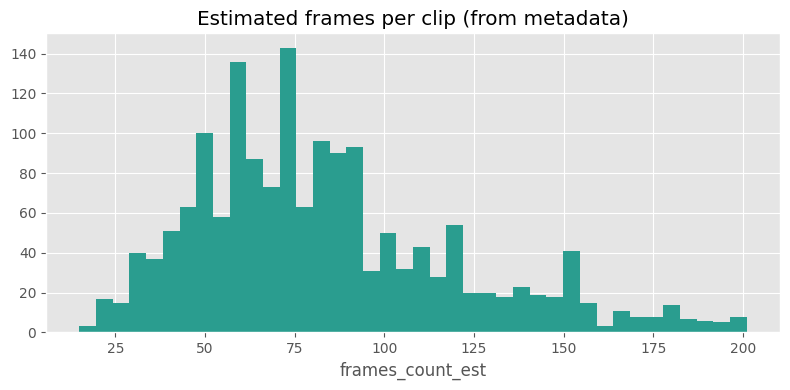

In [6]:
# Quick frame-count stats from metadata (before normalization/extraction)
start_raw = pd.to_numeric(work_df['start_frame'], errors='coerce').round()
end_raw = pd.to_numeric(work_df['end_frame'], errors='coerce').round()
# Mirror extraction logic: swap reversed ranges, convert to 0-based, clamp start >= 0
start_ord = pd.Series(np.minimum(start_raw, end_raw), index=work_df.index)
end_ord = pd.Series(np.maximum(start_raw, end_raw), index=work_df.index)
start_idx = pd.Series(np.maximum(0, start_ord - 1), index=work_df.index)
end_idx = pd.Series(np.maximum(start_idx, end_ord - 1), index=work_df.index)
work_df_stats = work_df.copy()
work_df_stats['frames_count_est'] = end_idx - start_idx + 1
frames = work_df_stats['frames_count_est']
frames = frames[np.isfinite(frames) & (frames > 0)].astype(float)
invalid_rows = len(work_df_stats) - len(frames)
print(f'Rows with valid estimated frames_count: {len(frames)}/{len(work_df_stats)}')
print(f'Rows skipped (invalid start/end): {invalid_rows}')
if len(frames) == 0:
    print('No valid estimated frame counts to summarize.')
else:
    q = frames.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    stats = pd.Series(
        {
            'count': int(frames.count()),
            'mean': frames.mean(),
            'std': frames.std(ddof=1) if len(frames) > 1 else 0.0,
            'min': frames.min(),
            'p01': q.loc[0.01],
            'p05': q.loc[0.05],
            'p10': q.loc[0.10],
            'p25': q.loc[0.25],
            'median_p50': q.loc[0.50],
            'p75': q.loc[0.75],
            'p90': q.loc[0.90],
            'p95': q.loc[0.95],
            'p99': q.loc[0.99],
            'max': frames.max(),
            'iqr_p75_p25': q.loc[0.75] - q.loc[0.25],
        },
        name='frames_count_est',
    )
    display(stats.to_frame('value').round(3))
    fig, ax = plt.subplots(figsize=(8, 4))
    frames.hist(bins=40, ax=ax, color='#2a9d8f')
    ax.set_title('Estimated frames per clip (from metadata)')
    ax.set_xlabel('frames_count_est')
    plt.tight_layout()
    plt.show()


In [7]:
if RUN_PILOT_50:
    pilot_n = min(int(PILOT_SIZE), len(work_df))
    if pilot_n <= 0:
        print('Pilot skipped: no rows to process.')
    else:
        print(f'Running pilot on {pilot_n} recordings with MAX_WORKERS={MAX_WORKERS}')
        pilot_df_in = work_df.head(pilot_n).copy()
        t0 = time.perf_counter()
        pilot_df = process_dataframe(
            df_subset=pilot_df_in,
            output_dir=PILOT_OUTPUT_FRAMES_DIR,
            max_workers=MAX_WORKERS,
            progress_step=10,
        )
        pilot_elapsed = time.perf_counter() - t0
        pilot_ok = int((pilot_df['process_status'] == 'ok').sum()) if 'process_status' in pilot_df.columns else 0
        pilot_fail = len(pilot_df) - pilot_ok
        pilot_speed = (len(pilot_df) / pilot_elapsed) if pilot_elapsed > 0 else np.nan
        print(f'Pilot time: {pilot_elapsed:.2f} s')
        print(f'Pilot throughput: {pilot_speed:.3f} clips/sec')
        print(f'Pilot status: ok={pilot_ok}, failed={pilot_fail}')
        if 'process_status' in pilot_df.columns:
            display(pilot_df['process_status'].value_counts(dropna=False).to_frame('count'))
else:
    print('Pilot disabled. Set RUN_PILOT_50 = True to run this cell.')


Pilot disabled. Set RUN_PILOT_50 = True to run this cell.


Processed 25/1647
Processed 50/1647
Processed 75/1647
Processed 100/1647
Processed 125/1647
Processed 150/1647
Processed 175/1647
Processed 200/1647
Processed 225/1647
Processed 250/1647
Processed 275/1647
Processed 300/1647
Processed 325/1647
Processed 350/1647
Processed 375/1647
Processed 400/1647
Processed 425/1647
Processed 450/1647
Processed 475/1647
Processed 500/1647
Processed 525/1647
Processed 550/1647
Processed 575/1647
Processed 600/1647
Processed 625/1647
Processed 650/1647
Processed 675/1647
Processed 700/1647
Processed 725/1647
Processed 750/1647
Processed 775/1647
Processed 800/1647
Processed 825/1647
Processed 850/1647
Processed 875/1647
Processed 900/1647
Processed 925/1647
Processed 950/1647
Processed 975/1647
Processed 1000/1647
Processed 1025/1647
Processed 1050/1647
Processed 1075/1647
Processed 1100/1647
Processed 1125/1647
Processed 1150/1647
Processed 1175/1647
Processed 1200/1647
Processed 1225/1647
Processed 1250/1647
Processed 1275/1647
Processed 1300/1647
Pr

,count
process_status,
ok,1647


Successful clips: 1647
Failed clips: 0


,label,video_path,start_frame,end_frame,frames_path,frames_count
0,learn,MS-ASL/videos_MS_ASL_raw/msasl_raw_owXsDIKq4lk...,1251,1311.0,normalized_frames/topn_raw_jpg/learn/msasl_raw...,61
1,teacher,MS-ASL/videos_MS_ASL_raw/msasl_raw_UoITyyziLOw...,3527,3608.0,normalized_frames/topn_raw_jpg/teacher/msasl_r...,82
2,like,MS-ASL/videos_MS_ASL_raw/msasl_raw_rWIDL_GpaJc...,13941,14110.0,normalized_frames/topn_raw_jpg/like/msasl_raw_...,170
3,table,MS-ASL/videos_MS_ASL_raw/msasl_raw_P3tBJESDamE...,5944,6014.0,normalized_frames/topn_raw_jpg/table/msasl_raw...,71
4,student,kaggle_dataset/videos/55341.mp4,1,75.0,normalized_frames/topn_raw_jpg/student/55341__...,75
5,cousin,MS-ASL/videos_MS_ASL_raw/msasl_raw_7sZLZpm4n2E...,1481,1549.0,normalized_frames/topn_raw_jpg/cousin/msasl_ra...,69
6,water,MS-ASL/videos_MS_ASL_raw/msasl_raw_HPUrVQbnNiU...,1924,1974.0,normalized_frames/topn_raw_jpg/water/msasl_raw...,51
7,mother,kaggle_dataset/videos/69399.mp4,1,76.0,normalized_frames/topn_raw_jpg/mother/69399__s...,76
8,student,MS-ASL/videos_MS_ASL_raw/msasl_raw_UoITyyziLOw...,3610,3731.0,normalized_frames/topn_raw_jpg/student/msasl_r...,122
9,need,MS-ASL/videos_MS_ASL_raw/msasl_raw_5sILDEiOcQ0...,4246,4322.0,normalized_frames/topn_raw_jpg/need/msasl_raw_...,77


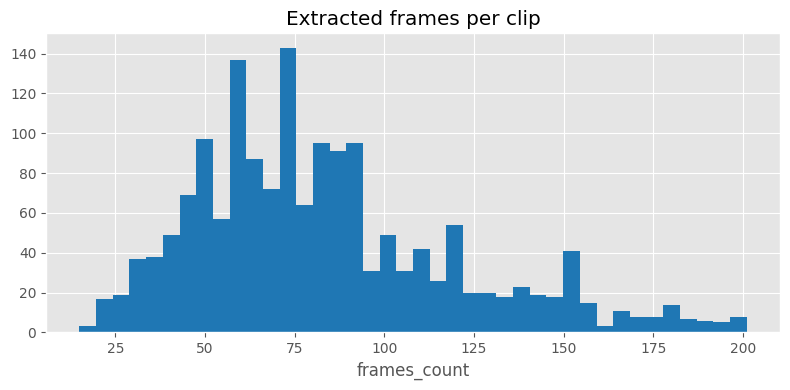

In [8]:
t0 = time.perf_counter()
result_df = process_dataframe(
    df_subset=work_df,
    output_dir=OUTPUT_FRAMES_DIR,
    max_workers=MAX_WORKERS,
    progress_step=25,
)
run_elapsed = time.perf_counter() - t0
print(f'\nFull run time: {run_elapsed:.2f} s')
if run_elapsed > 0:
    print(f'Full run throughput: {len(result_df) / run_elapsed:.3f} clips/sec')
status_counts = result_df['process_status'].value_counts(dropna=False) if 'process_status' in result_df.columns else pd.Series(dtype=int)
print('\nProcess status counts:')
display(status_counts.to_frame('count'))
ok_df = result_df[result_df['process_status'] == 'ok'].copy() if 'process_status' in result_df.columns else result_df.head(0).copy()
print('Successful clips:', len(ok_df))
print('Failed clips:', len(result_df) - len(ok_df))
if len(ok_df) > 0:
    preview_cols = ['label', 'video_path', 'start_frame', 'end_frame', 'frames_path', 'frames_count']
    preview_cols = [c for c in preview_cols if c in ok_df.columns]
    display(ok_df[preview_cols].head(10))
    fig, ax = plt.subplots(figsize=(8, 4))
    ok_df['frames_count'].dropna().astype(float).hist(bins=40, ax=ax, color='#1f77b4')
    ax.set_title('Extracted frames per clip')
    ax.set_xlabel('frames_count')
    plt.tight_layout()
    plt.show()


In [9]:
OUTPUT_METADATA_CSV.parent.mkdir(parents=True, exist_ok=True)
result_df.to_csv(OUTPUT_METADATA_CSV, index=False)
print('Saved metadata CSV:', OUTPUT_METADATA_CSV)
print('Output frames root:', OUTPUT_FRAMES_DIR)
if len(ok_df) > 0:
    sample_ok = ok_df.head(5)
    checks = []
    for p in sample_ok['frames_path']:
        fp = resolve_video_path(str(p), PROJECT_ROOT)
        checks.append((str(p), fp.exists(), count_extracted_frames(fp, FRAME_EXT) if fp.exists() else 0))
    display(pd.DataFrame(checks, columns=['frames_path', 'exists', 'jpg_count']))


Saved metadata CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\universal_metadata_topn_frames_raw.csv
Output frames root: C:\Users\kacpe\source\repos\szum\normalized_frames\topn_raw_jpg


,frames_path,exists,jpg_count
0,normalized_frames/topn_raw_jpg/learn/msasl_raw...,True,61
1,normalized_frames/topn_raw_jpg/teacher/msasl_r...,True,82
2,normalized_frames/topn_raw_jpg/like/msasl_raw_...,True,170
3,normalized_frames/topn_raw_jpg/table/msasl_raw...,True,71
4,normalized_frames/topn_raw_jpg/student/55341__...,True,75
